CC1 — Partie 2 : Régression, Dataset House Prices
Comparaison de MLPRegressor (Scikit-learn), Keras et TensorFlow

Réalisé par : KNIKSI YASSIR

Avant de lancer : exécuter la cellule 1, puis importer le fichier housing.csv.

Métriques d’évaluation

**R²**, **RMSE**, **MAE**

In [22]:
import pandas as pd
from IPython.display import display

df = pd.read_csv("housing.csv")
print("Dimensions :", df.shape)
display(df.head(10))
df.info()

Dimensions : (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


## Imports et préparation des données

In [4]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

SEED, EPOCHS = 42, 100
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

df = pd.read_csv("housing.csv")

# Variables yes/no -> 1/0 ; furnishingstatus -> one-hot
bin_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
for c in bin_cols:
    df[c] = (df[c] == "yes").astype(int)
df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True, dtype=int)

X = df.drop(columns="price").values.astype("float32")
y = df["price"].values.astype("float32").reshape(-1, 1)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=SEED)
sx, sy = StandardScaler().fit(Xtr), StandardScaler().fit(ytr)
Xtr, Xte = sx.transform(Xtr).astype("float32"), sx.transform(Xte).astype("float32")
ytr_s, yte_s = sy.transform(ytr).astype("float32"), sy.transform(yte).astype("float32")
n_features = Xtr.shape[1]
print("Variables :", n_features, "| Train :", len(Xtr), "| Test :", len(Xte))

def metrics(pred_scaled):
    pred = sy.inverse_transform(np.asarray(pred_scaled).reshape(-1, 1))
    return {"R2": r2_score(yte, pred),
            "RMSE": float(np.sqrt(mean_squared_error(yte, pred))),
            "MAE": mean_absolute_error(yte, pred)}, pred.ravel()

def plot_model(loss, vloss, pred, title, m, color):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
    ax[0].plot(loss, label="Train", color=color)
    if vloss is not None:
        ax[0].plot(vloss, label="Test", color="gray", ls="--")
    ax[0].set(title=f"{title} : Loss (MSE, échelle normalisée)", xlabel="Epoch / Itération", ylabel="Loss")
    ax[0].set_yscale("log"); ax[0].legend(); ax[0].grid(alpha=.3)
    yt = yte.ravel()
    ax[1].scatter(yt, pred, alpha=.6, color=color)
    lim = [min(yt.min(), pred.min()), max(yt.max(), pred.max())]
    ax[1].plot(lim, lim, "k--", lw=1)
    ax[1].set(title=f"{title} : Prédit vs Réel (R² = {m['R2']:.3f})", xlabel="Prix réel", ylabel="Prix prédit")
    ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

Variables : 13 | Train : 436 | Test : 109


## 2.1 Scikit-learn : MLPRegressor

{'R2': 0.6173, 'RMSE': 1390901.5502, 'MAE': 1032533.8125}


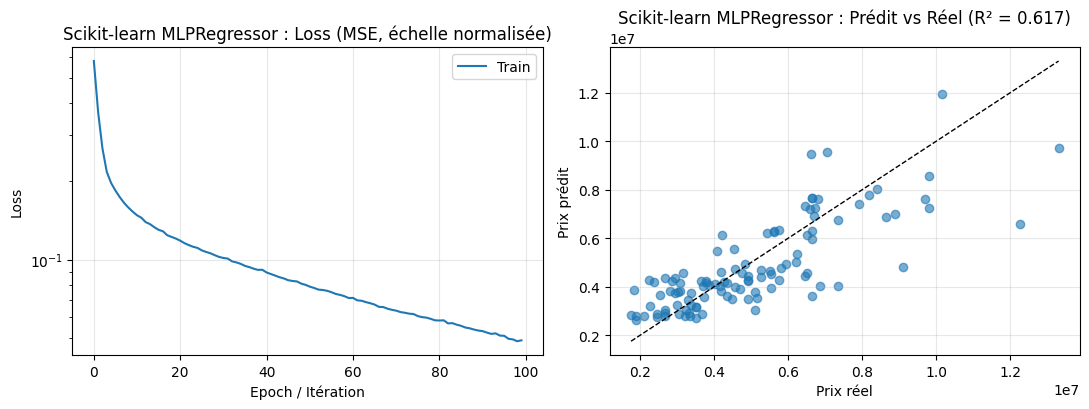

In [5]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
mlp = MLPRegressor(hidden_layer_sizes=(32, 16), activation="relu", batch_size=32,
                   max_iter=EPOCHS, random_state=SEED).fit(Xtr, ytr_s.ravel())
m_sk, p_sk = metrics(mlp.predict(Xte))
print({k: round(v, 4) for k, v in m_sk.items()})
plot_model(mlp.loss_curve_, None, p_sk, "Scikit-learn MLPRegressor", m_sk, "#1f77b4")

## 2.2 TensorFlow / Keras

{'R2': 0.6189, 'RMSE': 1387835.9493, 'MAE': 998208.375}


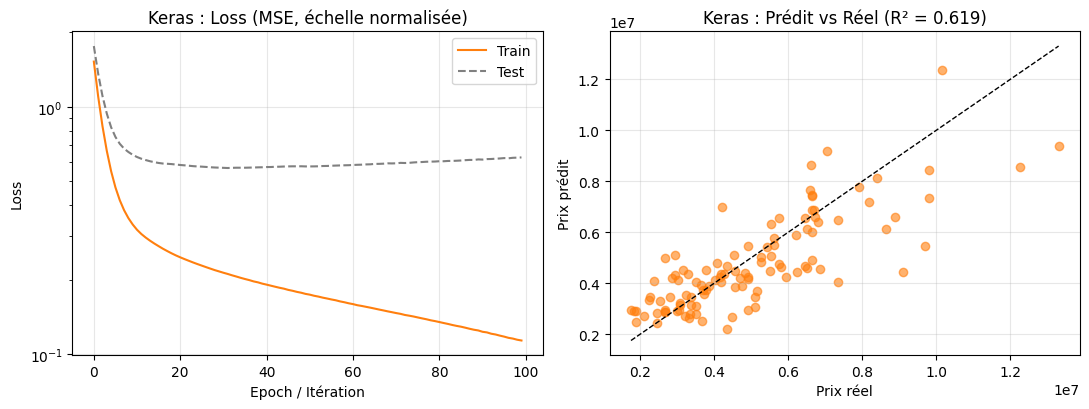

In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_features,)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1),
])
model.compile(optimizer="adam", loss="mse")
h = model.fit(Xtr, ytr_s, validation_data=(Xte, yte_s), epochs=EPOCHS, batch_size=32, verbose=0).history
m_keras, p_keras = metrics(model.predict(Xte, verbose=0))
print({k: round(v, 4) for k, v in m_keras.items()})
plot_model(h["loss"], h["val_loss"], p_keras, "Keras", m_keras, "#ff7f0e")

## TensorFlow bas niveau (GradientTape)

{'R2': 0.5933, 'RMSE': 1433713.0927, 'MAE': 1080473.375}


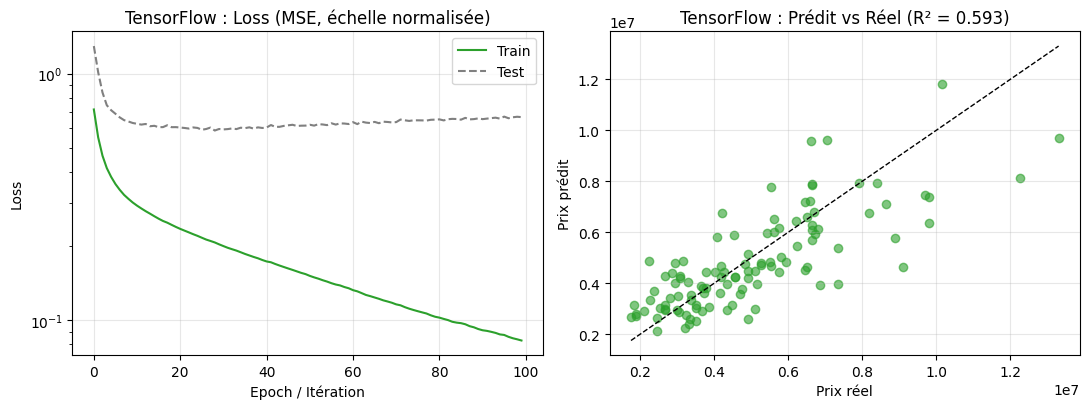

In [7]:
init = tf.keras.initializers.GlorotUniform(seed=SEED)
W1, b1 = tf.Variable(init((n_features, 32))), tf.Variable(tf.zeros(32))
W2, b2 = tf.Variable(init((32, 16))),         tf.Variable(tf.zeros(16))
W3, b3 = tf.Variable(init((16, 1))),          tf.Variable(tf.zeros(1))
params = [W1, b1, W2, b2, W3, b3]

def forward(x):
    x = tf.nn.relu(tf.matmul(x, W1) + b1)
    x = tf.nn.relu(tf.matmul(x, W2) + b2)
    return tf.matmul(x, W3) + b3

mse = lambda yt, yp: tf.reduce_mean(tf.square(yt - yp))
opt = tf.keras.optimizers.Adam(0.001)

L, VL = [], []
ds = tf.data.Dataset.from_tensor_slices((Xtr, ytr_s)).shuffle(len(Xtr), seed=SEED).batch(32)
for _ in range(EPOCHS):
    for xb, yb in ds:
        with tf.GradientTape() as tape:
            l = mse(yb, forward(xb))
        opt.apply_gradients(zip(tape.gradient(l, params), params))
    L.append(float(mse(ytr_s, forward(Xtr)))); VL.append(float(mse(yte_s, forward(Xte))))

m_tf, p_tf = metrics(forward(Xte).numpy())
print({k: round(v, 4) for k, v in m_tf.items()})
plot_model(L, VL, p_tf, "TensorFlow", m_tf, "#2ca02c")

## 3. Comparaison des modèles

                     Modèle     R2         RMSE          MAE
MLPRegressor (scikit-learn) 0.6173 1390901.5502 1032533.8125
                      Keras 0.6189 1387835.9493  998208.3750
  TensorFlow (GradientTape) 0.5933 1433713.0927 1080473.3750

Meilleur modèle (R² le plus élevé) : Keras


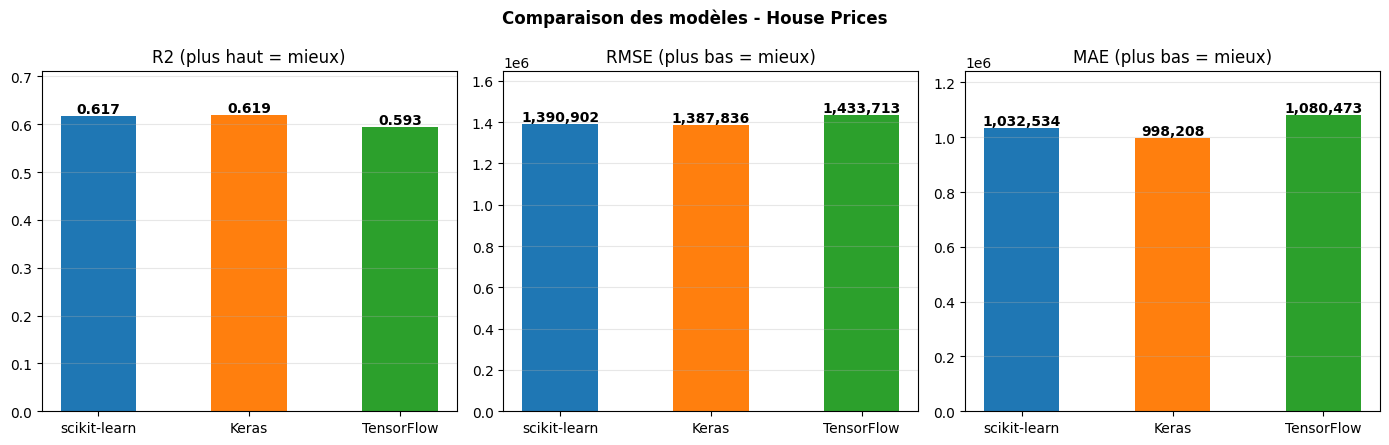

In [8]:
res = pd.DataFrame({"Modèle": ["MLPRegressor (scikit-learn)", "Keras", "TensorFlow (GradientTape)"],
                    "R2": [m_sk["R2"], m_keras["R2"], m_tf["R2"]],
                    "RMSE": [m_sk["RMSE"], m_keras["RMSE"], m_tf["RMSE"]],
                    "MAE": [m_sk["MAE"], m_keras["MAE"], m_tf["MAE"]]})
print(res.round(4).to_string(index=False))
best = res.loc[res["R2"].idxmax(), "Modèle"]
print("\nMeilleur modèle (R² le plus élevé) :", best)

names, cols = ["scikit-learn", "Keras", "TensorFlow"], ["#1f77b4", "#ff7f0e", "#2ca02c"]
fig, ax = plt.subplots(1, 3, figsize=(14, 4.5))
for a, metric, fmt in zip(ax, ["R2", "RMSE", "MAE"], ["{:.3f}", "{:,.0f}", "{:,.0f}"]):
    bars = a.bar(names, res[metric], color=cols, width=0.5)
    for b, v in zip(bars, res[metric]):
        a.text(b.get_x() + b.get_width()/2, v, fmt.format(v), ha="center", va="bottom", fontweight="bold")
    a.set_title(metric + (" (plus haut = mieux)" if metric == "R2" else " (plus bas = mieux)"))
    a.grid(axis="y", alpha=.3)
    a.set_ylim(0, res[metric].max() * 1.15)
plt.suptitle("Comparaison des modèles - House Prices", fontweight="bold")
plt.tight_layout(); plt.show()